In [1]:
from xgboost import XGBClassifier
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import (accuracy_score, precision_score,confusion_matrix, f1_score,recall_score, auc, roc_curve,ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import tracemalloc


In [2]:
phishing = fetch_ucirepo(id=327)
x = phishing.data.features
y = phishing.data.targets.values.ravel()

print(f"Dataset loaded: {x.shape[0]} samples, {x.shape[1]} features")

Dataset loaded: 11055 samples, 30 features


In [3]:
x_trn,x_tst,y_trn,y_tst = train_test_split(x,y,test_size=0.3,random_state=42)

In [4]:
scaler = joblib.load("scaler.pkl")
x_trn = scaler.transform(x_trn)
x_tst = scaler.transform(x_tst)

In [5]:
y_trn_xgb = np.where(y_trn == -1, 0, y_trn)
y_tst_xgb = np.where(y_tst == -1, 0, y_tst)

xgb = XGBClassifier(n_estimators=100,
                    eval_metric='logloss',
                    random_state=42)
xgb.fit(x_trn, y_trn_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
start = time.time()
y_pred = xgb.predict(x_tst)
time1 = time.time() - start

tracemalloc.start()
_ = xgb.predict(x_tst)
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Prediction Time  : {time1:.6f} seconds")
print(f"Memory (current) : {current_mem / 1024:.2f} KB")
print(f"Memory (peak)    : {peak_mem / 1024:.2f} KB")

Prediction Time  : 0.007882 seconds
Memory (current) : 31.58 KB
Memory (peak)    : 51.38 KB


In [7]:
joblib.dump(xgb, "xgbModel.pkl")
print("Model saved as xgbModel.pkl")

Model saved as xgbModel.pkl


In [8]:
train_accuracy = xgb.score(x_trn, y_trn_xgb)
test_accuracy  = accuracy_score(y_tst_xgb, y_pred)

print("\n========== OVERFITTING CHECK ==========")
print(f"Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy     : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"Difference        : {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_accuracy - test_accuracy) < 0.02:
    print("Status            : No Overfitting (difference < 2%)")
elif abs(train_accuracy - test_accuracy) < 0.05:
    print("Status            : Slight Overfitting (difference 2-5%)")
else:
    print("Status            : Overfitting detected (difference > 5%)")


========== OVERFITTING CHECK ==========
Training Accuracy : 0.9871 (98.71%)
Test Accuracy     : 0.9699  (96.99%)
Difference        : 0.0172
Status            : No Overfitting (difference < 2%)


In [9]:
accuracy        = accuracy_score(y_tst_xgb, y_pred)
precision       = precision_score(y_tst_xgb, y_pred)
recall          = recall_score(y_tst_xgb, y_pred)
f1score         = f1_score(y_tst_xgb, y_pred)
confusionMatrix = confusion_matrix(y_tst_xgb, y_pred)

print("\n========== XGBOOST RESULTS ==========")
print(f"Accuracy  = {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision = {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall    = {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1 Score  = {f1score:.4f}  ({f1score*100:.2f}%)")
print(f"\nPrediction Time : {time1:.6f} sec")
print(f"Peak Memory     : {peak_mem / 1024:.2f} KB")


========== XGBOOST RESULTS ==========
Accuracy  = 0.9699  (96.99%)
Precision = 0.9647  (96.47%)
Recall    = 0.9831  (98.31%)
F1 Score  = 0.9738  (97.38%)

Prediction Time : 0.007882 sec
Peak Memory     : 51.38 KB


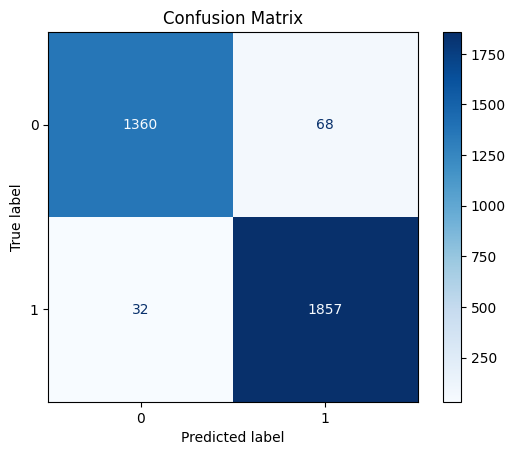

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [11]:
y_prob = xgb.predict_proba(x_tst)[:, 1]
fpr, tpr, _ = roc_curve(y_tst_xgb, y_prob)
roc_auc = auc(fpr, tpr)

print(f"\nROC-AUC Score = {roc_auc:.4f}")


ROC-AUC Score = 0.9960


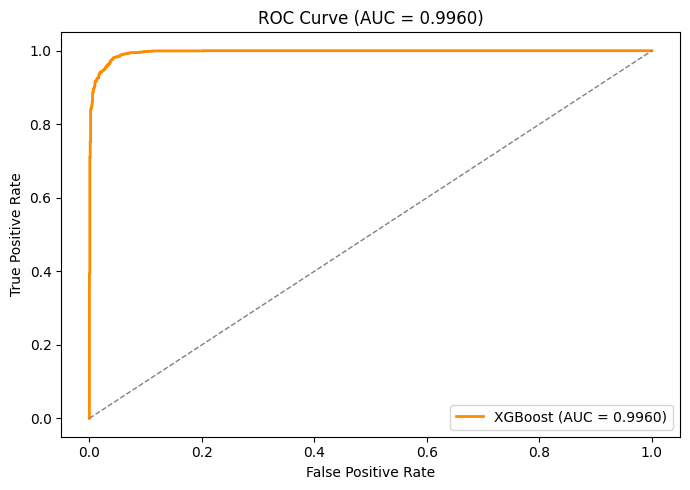

ROC curve saved as roc_xgboost.png


In [12]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.4f)" % roc_auc)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_xgboost.png", dpi=150)
plt.show()
print("ROC curve saved as roc_xgboost.png")

In [13]:
summary = pd.DataFrame({
    "Model":         ["XGBoost"],
    "Accuracy (%)":  [round(accuracy * 100, 2)],
    "Precision (%)": [round(precision * 100, 2)],
    "Recall (%)":    [round(recall * 100, 2)],
    "F1-Score (%)":  [round(f1score * 100, 2)],
    "ROC-AUC":       [round(roc_auc, 4)],
    "Pred Time (s)": [round(time1, 6)],
    "Peak Mem (KB)": [round(peak_mem / 1024, 2)]
})

print("\n========== SUMMARY TABLE ==========")
print(summary.to_string(index=False))


========== SUMMARY TABLE ==========
  Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC  Pred Time (s)  Peak Mem (KB)
XGBoost         96.99          96.47       98.31         97.38    0.996       0.007882          51.38
